In [1]:
"""
SRCNN Super-Resolution Pipeline for Sen2Venus Dataset
======================================================
Sites: FGMANAUS + ESTUAMAR
Bands: B2, B3, B4, B8 (4-channel)
Task : 10 m (LR)  →  5 m (HR)  [×2 upscaling]

Hyperparameters
---------------
Kernel sizes      : 9 × 9  →  1 × 1  →  5 × 5   (Dong et al., 2014)
Feature channels  : 64  →  32  →  4
Learning rate     : 1e-4 (f1, f2)  /  1e-5 (f3 / output layer)
Batch size        : 16
Epochs            : 30
Train/Test split  : 80 / 20  (random_state = 42, pooled across both sites)
Upscale method    : Bicubic (pre-upscale LR before feeding to SRCNN)
Loss              : MSE
"""

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from math import log10
from google.colab import drive
from functools import lru_cache

In [2]:
import torch_xla.core.xla_model as xm
import torch_xla.debug.metrics as dmetrics
import torch_xla.distributed.xla_multiprocessing as xmp

# Set the device to XLA (TPU)
DEVICE = xm.xla_device()

print(f"Using device: {DEVICE}")

/tmp/ipykernel_745/2257296394.py:6: DeprecationWarning: Use torch_xla.device instead
  DEVICE = xm.xla_device()


Using device: xla:0


In [3]:
# 0. Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# DEVICE is already defined by the TPU setup cell (e0ed7e99)
# if torch.cuda.is_available():
#     DEVICE = torch.device("cuda")
#     torch.cuda.manual_seed(SEED)
#     torch.cuda.manual_seed_all(SEED)
#     print(f"Using device: {DEVICE} ({torch.cuda.get_device_name(0)})
# else:
#     DEVICE = torch.device("cpu")
#     print("CUDA not available, using CPU")

In [4]:
# Mount Google Drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

# 1.  Site paths
SITES = {
    "FGMANAUS": "/content/drive/MyDrive/Data/Sen2Venus/FGMANAUS",
    "ESTUAMAR": "/content/drive/MyDrive/Data/Sen2Venus/ESTUAMAR",
    "SUDOUE-6": "/content/drive/MyDrive/Data/Sen2Venus/SUDOUE-6",
    "ANJI"    : "/content/drive/MyDrive/Data/Sen2Venus/ANJI",
}

records = []

for site, base in SITES.items():
    all_files = os.listdir(base)

    # All LR files: contain "_10m_b2b3b4b8" and end with ".pt"
    lr_files = sorted([
        f for f in all_files
        if "_10m_b2b3b4b8" in f and f.endswith(".pt")
    ])

    if not lr_files:
        print(f"WARNING: No LR .pt files found in {base}")
        continue

    for lr_file in lr_files:
        # Derive matching HR filename by swapping resolution token
        hr_file = lr_file.replace("_10m_b2b3b4b8", "_05m_b2b3b4b8")

        lr_path = os.path.join(base, lr_file)
        hr_path = os.path.join(base, hr_file)

        if not os.path.exists(hr_path):
            print(f"  WARNING: No HR match for {lr_file} — skipping.")
            continue

        # Load briefly just to read patch count, then free memory
        lr_tensor = torch.load(lr_path, weights_only=True).float()
        n_patches = lr_tensor.shape[0]
        del lr_tensor

        for i in range(n_patches):
            records.append({
                "site":    site,
                "lr_path": lr_path,
                "hr_path": hr_path,
                "patch":   i,
            })

    print(f"  {site}: {len(lr_files)} acquisition file(s) found")

df_all = pd.DataFrame(records)
print(f"\nTotal patches across all sites: {len(df_all)}")
print(df_all.groupby("site")["patch"].count().rename("patches").to_string())
print()

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
  FGMANAUS: 4 acquisition file(s) found
  ESTUAMAR: 13 acquisition file(s) found
  SUDOUE-6: 14 acquisition file(s) found
  ANJI: 16 acquisition file(s) found

Total patches across all sites: 5790
site
ANJI        2314
ESTUAMAR     912
FGMANAUS     129
SUDOUE-6    2435



In [5]:
# 2. Train / Test split
train_df, test_df = train_test_split(df_all, test_size=0.20, random_state=42, shuffle=True)

# ← PASTE HERE, right after the split
train_df = train_df.sort_values(["lr_path", "patch"]).reset_index(drop=True)
test_df  = test_df.sort_values(["lr_path", "patch"]).reset_index(drop=True)

print(f"Train patches : {len(train_df)}")
print(f"Test  patches : {len(test_df)}")

Train patches : 4632
Test  patches : 1158


In [6]:
class Sen2VenusDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, cache_size: int = 8):
        self.df = dataframe.reset_index(drop=True)
        self.cache_size = cache_size
        # LRU cache: only keeps last `cache_size` files in RAM
        self._load_cached = lru_cache(maxsize=cache_size)(self._load_file)

    def _load_file(self, path: str) -> torch.Tensor:
        """Load one .pt file, normalise, return tensor."""
        t = torch.load(path, weights_only=True).float()
        return t / 10000.0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        lr_all = self._load_cached(row["lr_path"])
        hr_all = self._load_cached(row["hr_path"])

        i  = int(row["patch"])
        lr = lr_all[i].clone()   # clone so cache tensor isn't mutated
        hr = hr_all[i].clone()

        _, H, W = hr.shape
        lr_up = F.interpolate(
            lr.unsqueeze(0), size=(H, W),
            mode="bicubic", align_corners=False
        ).squeeze(0)

        return lr_up.clamp(0, 1), hr.clamp(0, 1)

train_ds = Sen2VenusDataset(train_df, cache_size=4)
test_ds  = Sen2VenusDataset(test_df,  cache_size=4)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=0, pin_memory=False)

In [7]:
# ─────────────────────────────────────────────────────────────
# 4.  SRCNN model
#  Three-layer design from Dong et al. (2014), adapted for
#  4-band (B2 B3 B4 B8) satellite imagery.
#
#  Layer   Kernel   Filters   Role
#  ──────  ───────  ───────   ────────────────────────────────
#  Conv1   9 x 9      64      Patch extraction & representation
#  Conv2   1 x 1      32      Non-linear mapping
#  Conv3   5 x 5       4      Reconstruction
# ─────────────────────────────────────────────────────────────
class SRCNN(nn.Module):

    def __init__(self, num_channels: int = 4):
        super().__init__()
        self.conv1 = nn.Conv2d(num_channels,  64,           kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64,            32,           kernel_size=1, padding=0)
        self.conv3 = nn.Conv2d(32,            num_channels, kernel_size=5, padding=2)
        self.relu  = nn.ReLU(inplace=True)

        # Initialisation from original paper
        for layer in [self.conv1, self.conv2, self.conv3]:
            nn.init.normal_(layer.weight, mean=0, std=0.001)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        return self.conv3(x)

model = SRCNN(num_channels=4).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}\n")

SRCNN(
  (conv1): Conv2d(4, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv3): Conv2d(32, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)
Trainable parameters: 26,084



In [8]:
# 5.  Loss & optimiser Dong et al. recommend a 10x lower LR for the last layer.
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 6.  Utility metrics
def psnr(mse_val: float, max_val: float = 1.0) -> float:
    if mse_val == 0:
        return float("inf")
    return 10 * log10(max_val ** 2 / mse_val)

def ssim_batch(pred: torch.Tensor, target: torch.Tensor,C1: float = 0.01**2, C2: float = 0.03**2) -> float:
    """
    Mean SSIM over every (sample, channel) pair in the batch.
    pred / target: [B, C, H, W], values in [0, 1].
    """
    pred   = pred.detach().cpu().float()
    target = target.detach().cpu().float()
    B, C, _, _ = pred.shape

    vals = []
    for b in range(B):
        for c in range(C):
            p = pred[b, c]
            t = target[b, c]
            mu_p,  mu_t  = p.mean().item(),  t.mean().item()
            sig_p, sig_t = p.var().item(),   t.var().item()
            sig_pt       = ((p - mu_p) * (t - mu_t)).mean().item()

            num = (2 * mu_p * mu_t + C1) * (2 * sig_pt + C2)
            den = (mu_p**2 + mu_t**2 + C1) * (sig_p + sig_t + C2)
            vals.append(num / (den + 1e-8))

    return float(np.mean(vals))

In [ ]:
# 6. Checkpoint loading
CHECKPOINT_PATH = '/content/drive/MyDrive/Data/srcnn_checkpoint.pt'

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    START_EPOCH       = checkpoint['epoch'] + 1
    train_losses      = checkpoint['train_losses']
    val_losses        = checkpoint['val_losses']
    val_psnrs         = checkpoint['val_psnrs']
    val_ssims         = checkpoint['val_ssims']
    print(f"Resumed from epoch {checkpoint['epoch']} — starting at epoch {START_EPOCH}")

else:
    START_EPOCH  = 1
    train_losses = []
    val_losses   = []
    val_psnrs    = []
    val_ssims    = []
    print("No checkpoint found — starting fresh")


# 7. Training loop
EPOCHS = 4  # epochs TO RUN this session, not total

for epoch in range(START_EPOCH, START_EPOCH + EPOCHS):
    # ── train ──
    model.train()
    epoch_loss = 0.0
    for lr_in, hr in train_loader:
        lr_in, hr = lr_in.to(DEVICE), hr.to(DEVICE)
        pred = model(lr_in)
        loss = criterion(pred, hr)
        optimizer.zero_grad()
        loss.backward()
        xm.optimizer_step(optimizer)
        xm.mark_step()
        epoch_loss += loss.item() * lr_in.size(0)

    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)

    # ── evaluate on test set ──
    model.eval()
    val_loss = 0.0
    ep_psnr, ep_ssim = [], []

    with torch.no_grad():
        for lr_in, hr in test_loader:
            lr_in, hr = lr_in.to(DEVICE), hr.to(DEVICE)
            pred = model(lr_in).clamp(0, 1)
            loss = criterion(pred, hr)
            val_loss += loss.item() * lr_in.size(0)
            ep_psnr.append(psnr(loss.item()))
            ep_ssim.append(ssim_batch(pred, hr))
            xm.mark_step()

    val_loss /= len(test_ds)
    val_losses.append(val_loss)
    val_psnrs.append(float(np.mean(ep_psnr)))
    val_ssims.append(float(np.mean(ep_ssim)))

    print(f"Epoch {epoch:3d}  "
          f"Train MSE: {epoch_loss:.6f}  "
          f"Val MSE: {val_loss:.6f}  "
          f"PSNR: {val_psnrs[-1]:.2f} dB  "
          f"SSIM: {val_ssims[-1]:.4f}")

    # ── save checkpoint after every epoch ──
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses':         train_losses,
        'val_losses':           val_losses,
        'val_psnrs':            val_psnrs,
        'val_ssims':            val_ssims,
    }, CHECKPOINT_PATH)
    print(f"  Checkpoint saved (epoch {epoch})")

Resumed from epoch 4 — starting at epoch 5


/tmp/ipykernel_745/2321429803.py:38: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipykernel_745/2321429803.py:57: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch   5  Train MSE: 0.001082  Val MSE: 0.001028  PSNR: 29.76 dB  SSIM: 0.6384
  Checkpoint saved (epoch 5)


In [10]:
# 8.  Final test-set evaluation
model.eval()
srcnn_mse_list,   srcnn_psnr_list,   srcnn_ssim_list = [], [], []
bicubic_mse_list, bicubic_psnr_list                  = [], []

with torch.no_grad():
    # Wrap test_loader with MpDeviceLoader for TPU
    for lr_up, hr in test_loader:
        # Data is already on DEVICE because of MpDeviceLoader
        lr_up, hr = lr_up.to(DEVICE), hr.to(DEVICE)
        # SRCNN prediction
        pred  = model(lr_up).clamp(0, 1)
        s_mse = criterion(pred, hr).item()
        srcnn_mse_list.append(s_mse)
        srcnn_psnr_list.append(psnr(s_mse))
        srcnn_ssim_list.append(ssim_batch(pred, hr))

        # Bicubic baseline (lr_up is already bicubic-upscaled)
        b_mse = criterion(lr_up, hr).item()
        bicubic_mse_list.append(b_mse)
        bicubic_psnr_list.append(psnr(b_mse))
        xm.mark_step()

print("\n" + "=" * 55)
print("        FINAL TEST-SET PERFORMANCE")
print("=" * 55)
print(f"{'Metric':<22} {'Bicubic':>12} {'SRCNN':>12}")
print("-" * 55)
print(f"{'MSE':<22} "
      f"{np.mean(bicubic_mse_list):>12.6f} "
      f"{np.mean(srcnn_mse_list):>12.6f}")
print(f"{'PSNR (dB)':<22} "
      f"{np.mean(bicubic_psnr_list):>12.2f} "
      f"{np.mean(srcnn_psnr_list):>12.2f}")
print(f"{'SSIM':<22} "
      f"{'—':>12} "
      f"{np.mean(srcnn_ssim_list):>12.4f}")
print("=" * 55)

/tmp/ipykernel_745/2447549014.py:22: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()



        FINAL TEST-SET PERFORMANCE
Metric                      Bicubic        SRCNN
-------------------------------------------------------
MSE                        0.000217     0.001112
PSNR (dB)                     36.69        29.61
SSIM                              —       0.6525


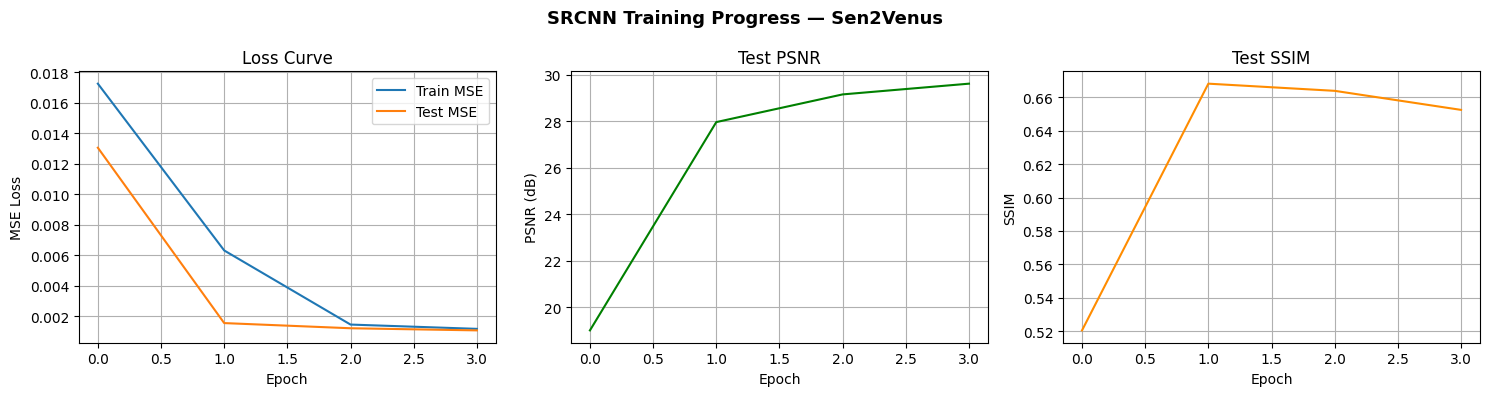

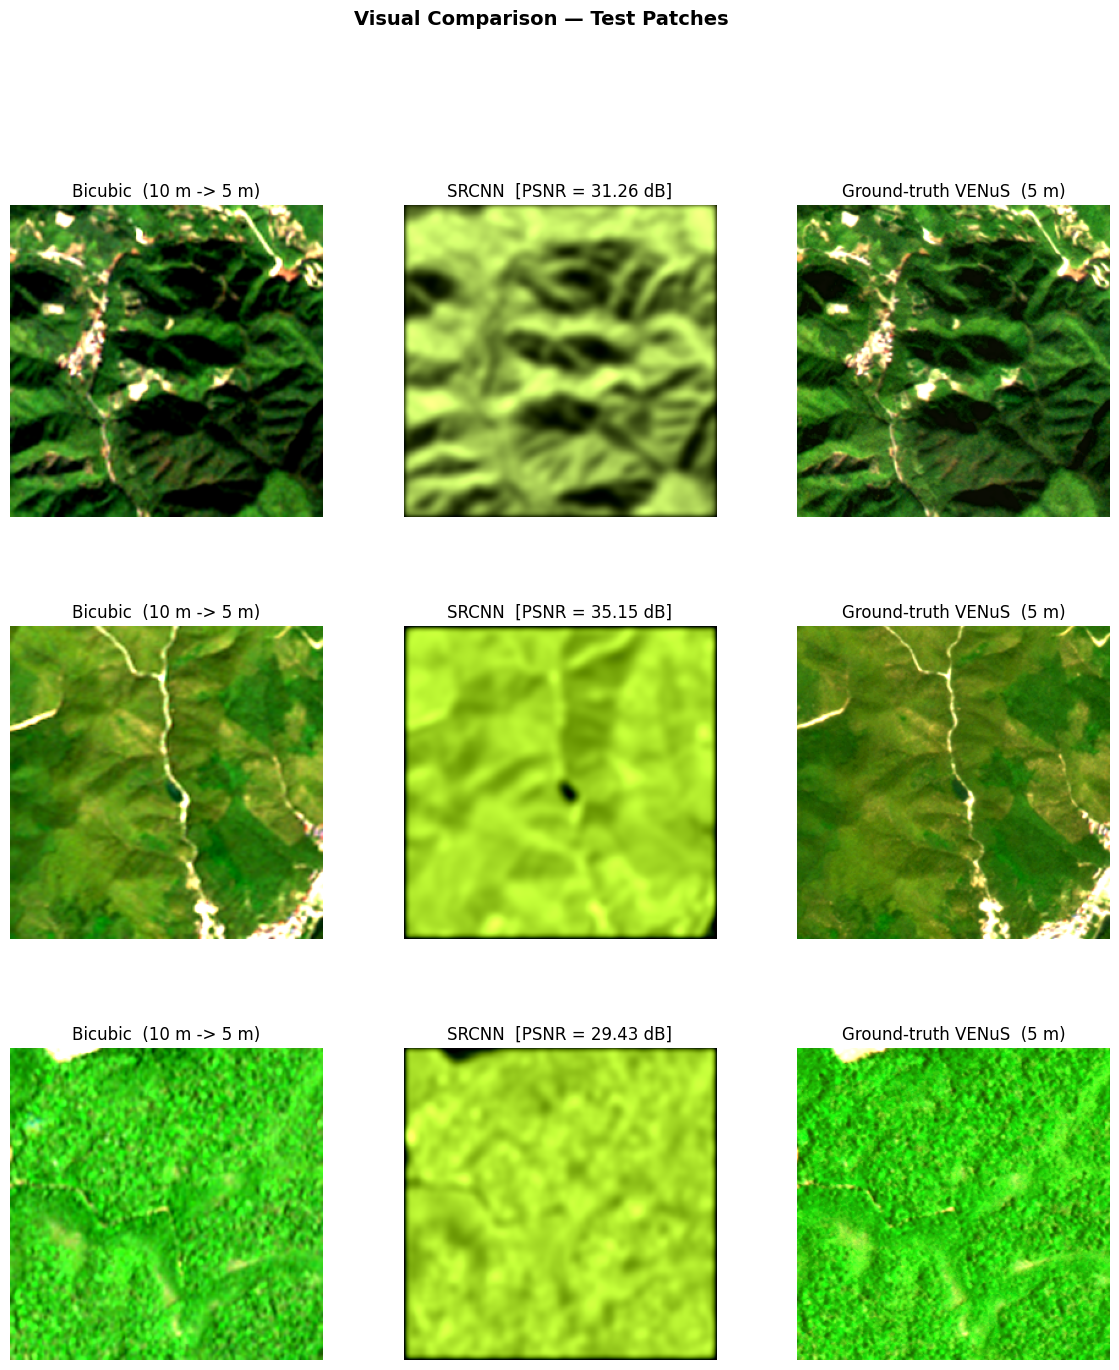


Done. Saved: srcnn_training_curves.png  &  srcnn_visual_comparison.png


In [11]:
# 9.  Plots
# 9a — Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, label="Train MSE")
axes[0].plot(val_losses,   label="Test MSE")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(val_psnrs, color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("Test PSNR"); axes[1].grid(True)

axes[2].plot(val_ssims, color="darkorange")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("SSIM")
axes[2].set_title("Test SSIM"); axes[2].grid(True)

plt.suptitle("SRCNN Training Progress — Sen2Venus", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("srcnn_training_curves.png", dpi=150)
plt.show()

# 9b — Visual comparison: Bicubic | SRCNN | Ground-truth
def stretch(img_tensor: torch.Tensor) -> np.ndarray:
    """Contrast-stretch [3, H, W] tensor to [H, W, 3] numpy for display."""
    img     = img_tensor.permute(1, 2, 0).cpu().numpy()
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)


model.eval()
n_show      = 3
sample_idxs = random.sample(range(len(test_ds)), n_show)

fig = plt.figure(figsize=(15, 5 * n_show))
gs  = gridspec.GridSpec(n_show, 3, hspace=0.35, wspace=0.05)

with torch.no_grad():
    for row_idx, si in enumerate(sample_idxs):
        lr_up, hr = test_ds[si]
        pred      = model(lr_up.unsqueeze(0).to(DEVICE)).squeeze(0).clamp(0, 1).cpu()

        # Band order in tensor: [B2, B3, B4, B8]
        # RGB display:           B4=idx2, B3=idx1, B2=idx0
        rgb_bic  = stretch(lr_up[[2, 1, 0]])
        rgb_pred = stretch(pred[[2, 1, 0]])
        rgb_hr   = stretch(hr[[2, 1, 0]])

        patch_psnr = psnr(F.mse_loss(pred, hr).item())

        ax0 = fig.add_subplot(gs[row_idx, 0])
        ax1 = fig.add_subplot(gs[row_idx, 1])
        ax2 = fig.add_subplot(gs[row_idx, 2])

        ax0.imshow(rgb_bic);  ax0.set_title("Bicubic  (10 m -> 5 m)");                ax0.axis("off")
        ax1.imshow(rgb_pred); ax1.set_title(f"SRCNN  [PSNR = {patch_psnr:.2f} dB]"); ax1.axis("off")
        ax2.imshow(rgb_hr);   ax2.set_title("Ground-truth VENuS  (5 m)");             ax2.axis("off")

plt.suptitle("Visual Comparison — Test Patches", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("srcnn_visual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone. Saved: srcnn_training_curves.png  &  srcnn_visual_comparison.png")